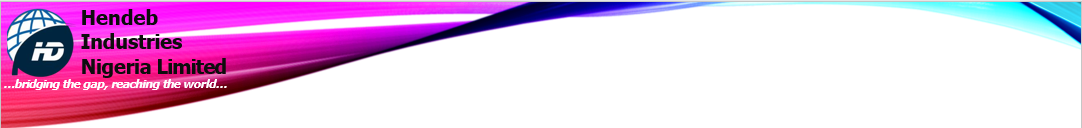
**3D-QSAR MODELING USING MACHINE ALGORITHMS**

This module focuses on modeling biological activity using three-dimensional
structural information. It introduces molecular alignment and spatial interactions.

Machine learning is applied to predict activity from descriptors. Visualization of
molecular fields is discussed. The module emphasizes understanding structure
activity relationships in three dimensions.

If we have experimental data on which molecules are active or inactive against a biological target and can characterize a molecule as a set of numbers (referred to as molecular descriptors), we can train a machine learning model to identify the pattern. This model can then be used to predict the activity of molecules that have never been tested in a lab.

**The QSAR process in simple terms**

Step 1: Get information
   ChEMBL database → IC50 values for your target → "these molecules inhibit the protein"
   
Step 2: Transform molecules into numbers
   "CCO" -> [MW=46, logP=-0.001, HBD=1, HBA=1, rings=0...] SMILES strings → molecular descriptors (200+ numerical properties)
   
Step 3: Develop a classifier
   What numerical patterns are predictive of activity, according to a machine learning model?
   
Step 4: Thoroughly validate
   5-fold cross-validation plus an independent test set => Is the model reliable?
   
Step 5: Examine your collection
   Utilize the model to determine the likelihood of your molecules becoming active.

Step 6: Interpret the SHAP analysis to determine which qualities are most important. (SAR)

---
**Regression vs. Classification**

In this notebook, compounds are classified as either INACTIVE (IC50 > threshold) or ACTIVE (IC50 < threshold). When data from several labs is noisy, this is more reliable than regression (which predicts precise IC50 values).

**Applicability Domain (AD)**

An essential idea for responsible QSAR. Only molecules that are comparable to the ones it was trained on can be accurately predicted by the model. This is illustrated by the Williams Plot, which flags molecules with high leverage (far from the chemical space of the training set); these predictions are extrapolations and should be carefully understood.

**SHAP Values**

"Why did the model predict this molecule is active?" is addressed by SHAP (SHapley Additive exPlanations). A SHAP value is assigned to each descriptor; a positive value indicates that it enhances activity, while a negative one indicates that it detracts from it. This serves as a link between SAR (Structure-Activity Relationship) and QSAR.

**Model validation metrics — what to look for**

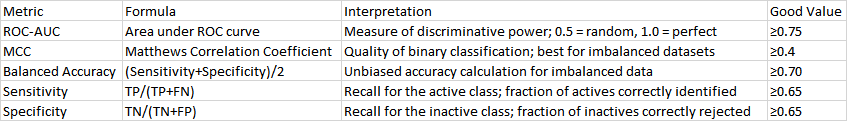

**Important:** A model with AUC < 0.65 has limited predictive power. The screening results can still be reported but must be interpreted with caution and validated by docking.





**How to interpret the results**

The probability score **(p)**
Each molecule gets a probability between **0** and **1.** This is NOT the probability of being a drug — it is the model's confidence that the molecule resembles the active compounds in the training set.

**p ≥ 0.80: strong prediction of activity**

**0.60 ≤ p < 0.80: moderate prediction**

**p < 0.60: weak prediction (not necessarily inactive — the model is uncertain)**

**The Applicability Domain flag**

✅ **Inside AD:** prediction is reliable — the molecule is similar to the training set

⚠️ **Outside AD:** prediction is an extrapolation — treat with caution but do not discard automatically. Many active natural products fall outside the AD of models trained on synthetic compounds.

**The SHAP summary plot**

Each dot is one molecule from your library
- **Color:** red = high value of that descriptor, blue = low value
- **X-axis position:** positive SHAP = increases predicted activity, negative = decreases it

**Example:** if **MolLogP** has high positive SHAP for red dots → high lipophilicity favors activity

**ADMET flags**

**Ro5 violations: 0-1** violations are acceptable for oral drugs; >1 suggests poor oral bioavailability unless the molecule is known to use active transport.

**PAINS alert:** structural patterns that cause assay interference. Not necessarily toxic — but be cautious and check in literature

**QED ≥ 0.5:** generally drug-like profile

In [1]:
# Installation & Configuration
print('⏳ Installing dependencies... (~4 min on first run)')
!pip install -q rdkit chembl-webresource-client xgboost shap mols2grid
print('\n✅ Installation complete. Continue with the configuration cell below.')

⏳ Installing dependencies... (~4 min on first run)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 109.5 MB/s eta 0:00:00

✅ Installation complete. Continue with the configuration cell below.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns, warnings, io, zipfile, os, re
warnings.filterwarnings('ignore')

from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Draw, rdMolDescriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import FilterCatalog
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                              matthews_corrcoef, classification_report,
                              confusion_matrix, roc_curve)
from sklearn.feature_selection import VarianceThreshold
import xgboost as xgb, shap
from numpy.linalg import pinv
from google.colab import files

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
C = {'act':'#27ae60','inact':'#e74c3c','top':'#8e44ad','neu':'#2980b9','warn':'#e67e22'}

# ── Utility functions ────────────────────────────────────────────────────
def smiles_ok(s):
    """Returns True if SMILES string is chemically valid."""
    try: return Chem.MolFromSmiles(str(s)) is not None
    except: return False

def standardize(s):
    """Removes salts and counterions, returns canonical parent fragment."""
    try:
        m = Chem.MolFromSmiles(str(s))
        if m is None: return None
        return Chem.MolToSmiles(rdMolStandardize.LargestFragmentChooser().choose(m))
    except: return None

calc_rdkit = MoleculeDescriptors.MolecularDescriptorCalculator(
    [d[0] for d in Descriptors.descList])
DESC_NAMES = list(calc_rdkit.GetDescriptorNames())

def get_descriptors(s):
    """Calculates all 2D RDKit descriptors for a SMILES string."""
    try:
        m = Chem.MolFromSmiles(str(s))
        return list(calc_rdkit.CalcDescriptors(m)) if m else [np.nan]*len(DESC_NAMES)
    except: return [np.nan]*len(DESC_NAMES)

def leverage(X_ref, X_query):
    """Calculates hat values (leverage) for applicability domain assessment."""
    inv = pinv(X_ref.T @ X_ref)
    return np.array([x @ inv @ x for x in X_query])

# Global state dictionary — stores all results between cells
STATE = {}
print('✅ Libraries loaded and utility functions defined.')
print(f'   RDKit descriptors available: {len(DESC_NAMES)}')

✅ Libraries loaded and utility functions defined.
   RDKit descriptors available: 217


**How to locate ChEMBL Target ID**

There are two choices available to you:

- **Option A:** If you are unsure of the ID, it is advised to search by name:
Run the cell down below. ChEMBL will provide matching targets when you provide the name of a protein. Make a copy of the desired target_chembl_id.

- **Option B:** Conduct an online search

Visit https://www.ebi.ac.uk/chembl/ Type Enter the name of your protein in the search bar (such as HIV protease, EGFR kinase, or dengue protease).
Select the Targets tab.
**Copy the CHEMBL_______ code** after locating the target that corresponds to yours.

**Advice:** Choose targets of type **SINGLE PROTEIN** over **ORGANISM** since they have more precise, reliable bioactivity information.

In [4]:
# ── Option A: Search by protein/disease name ─────────────────────────────
# Change the search term below to find your target
SEARCH_TERM = 'Plasmodium PfDHFR'

print(f'🔍 Searching ChEMBL for: "{SEARCH_TERM}"\n')
target_api = new_client.target
results = target_api.search(SEARCH_TERM)
df_targets = pd.DataFrame(list(results))[
    ['target_chembl_id','pref_name','target_type','organism']
].head(15)

print(f'Found {len(df_targets)} targets:\n')
display(df_targets)
print('\n💡 Copy the target_chembl_id you want and paste it in the configuration cell below.')

🔍 Searching ChEMBL for: "Plasmodium PfDHFR"

Found 15 targets:



,target_chembl_id,pref_name,target_type,organism
0,CHEMBL4888483,Plasmodium,ORGANISM,Plasmodium
1,CHEMBL364,Plasmodium falciparum,ORGANISM,Plasmodium falciparum
2,CHEMBL612653,Plasmodium berghei,ORGANISM,Plasmodium berghei
3,CHEMBL612889,Plasmodium yoelii,ORGANISM,Plasmodium yoelii
4,CHEMBL613883,Plasmodium cynomolgi,ORGANISM,Plasmodium cynomolgi
5,CHEMBL613256,Plasmodium chabaudi,ORGANISM,Plasmodium chabaudi
6,CHEMBL613011,Plasmodium knowlesi,ORGANISM,Plasmodium knowlesi
7,CHEMBL613257,Plasmodium malariae,ORGANISM,Plasmodium malariae
8,CHEMBL613013,Plasmodium vivax,ORGANISM,Plasmodium vivax
9,CHEMBL3301401,Plasmodium gallinaceum,ORGANISM,Plasmodium gallinaceum



💡 Copy the target_chembl_id you want and paste it in the configuration cell below.


In [5]:
# ── Therapeutic target ──────────────────────────────────────────────────
# Paste the ChEMBL ID from the search above (or from the ChEMBL website)
TARGET_ID   = 'CHEMBL613966'
TARGET_NAME = 'Plasmodium PfDHFR'

# ── Activity type ───────────────────────────────────────────────────────
# Common options: 'IC50', 'Ki', 'EC50', 'Kd'
# IC50: concentration inhibiting 50% activity (most common in ChEMBL)
# Ki:   inhibition constant (more thermodynamically rigorous, fewer data points)
ACTIVITY_TYPE = 'IC50'                # ← CHANGE if your target has more Ki data

# ── Activity cutoff ─────────────────────────────────────────────────────
# Molecules with value <= THRESHOLD_nM will be labeled ACTIVE
# Typical values:
#     100 nM  → strict (only highly potent compounds)
#    1000 nM  → stringent (potent compounds)
#   10000 nM  → standard (most in silico studies use this)
#  100000 nM  → broad (captures more actives, more noise)
THRESHOLD_nM = 10000                  # ← CHANGE according to your criteria

# ── Number of top candidates ────────────────────────────────────────────
TOP_N = 10                            # ← CHANGE: how many final candidates you want

# ── Optional modules ────────────────────────────────────────────────────
RUN_ADMET   = True    # True/False: Lipinski + Veber + PAINS + QED profile
RUN_ANALOGS = True    # True/False: generate analogs of Top 5 by scaffold modification

# ════════════════════════════════════════════════════════════════════════
STATE['config'] = {
    'target_id': TARGET_ID, 'target_name': TARGET_NAME,
    'activity_type': ACTIVITY_TYPE, 'threshold': THRESHOLD_nM,
    'top_n': TOP_N, 'admet': RUN_ADMET, 'analogs': RUN_ANALOGS
}

print('✅ Configuration saved:\n')
print(f'   Target:           {TARGET_ID} ({TARGET_NAME})')
print(f'   Activity type:    {ACTIVITY_TYPE}')
print(f'   Activity cutoff:  ≤ {THRESHOLD_nM:,} nM = ACTIVE')
print(f'   Top candidates:   {TOP_N}')
print(f'   ADMET module:     {"enabled" if RUN_ADMET else "disabled"}')
print(f'   Analogs module:   {"enabled" if RUN_ANALOGS else "disabled"}')

print('\n📋 Quick reference — common targets:')
ref = [

    ('Plasmodium PfDHFR',        'CHEMBL3718',   'IC50', 1000),

]
df_ref = pd.DataFrame(ref, columns=['Target','ChEMBL ID','Activity','Cutoff (nM)'])
display(df_ref)

✅ Configuration saved:

   Target:           CHEMBL613966 (Plasmodium PfDHFR)
   Activity type:    IC50
   Activity cutoff:  ≤ 10,000 nM = ACTIVE
   Top candidates:   10
   ADMET module:     enabled
   Analogs module:   enabled

📋 Quick reference — common targets:


,Target,ChEMBL ID,Activity,Cutoff (nM)
0,Plasmodium PfDHFR,CHEMBL3718,IC50,1000


**ChEMBL Dataset Download & Curation**

The importance of data curation
Bioactivity information from thousands of publications is combined by ChEMBL. This implies:

It's possible that the same compound was tested under various circumstances in several labs.

- Values with > or < relations, such as IC50 > 100 µM, are censored data; these are upper and lower bounds rather than actual measurements.

- Certain SMILES strings might not be valid or contain salts that should be eliminated.

- All of these problems are methodically addressed in the curation workflow below. A smaller, higher-quality dataset yields better models than a bigger, noisier one, thus losing molecules in this step is both expected and essential.

In [6]:
cfg = STATE['config']
print(f'📡 Downloading ChEMBL data for {cfg["target_id"]} ({cfg["target_name"]})...')

act_api = new_client.activity
activities = act_api.filter(
    target_chembl_id=cfg['target_id'],
    standard_type=cfg['activity_type']
).only(['molecule_chembl_id','canonical_smiles','standard_value',
        'standard_relation','pchembl_value','document_year',
        'assay_type','assay_description'])

df_raw = pd.DataFrame(list(activities))
print(f'\n✅ Downloaded: {len(df_raw)} {cfg["activity_type"]} records')

if len(df_raw) == 0:
    print('\n❌ No data found. Please check:')
    print('   1. Is the TARGET_ID correct?')
    print('   2. Try changing ACTIVITY_TYPE to "Ki" or "EC50"')
    print('   3. Verify the target has bioactivity data on chembl.ebi.ac.uk')
elif len(df_raw) < 30:
    print(f'\n⚠️  Only {len(df_raw)} records found — dataset may be too small for a robust model.')
    print('   Consider: changing activity type, using a related target, or adjusting the threshold.')
else:
    years = df_raw['document_year'].dropna().astype(int)
    print(f'   Publication years: {years.min()} – {years.max()}')
    print(f'   Assay types: {df_raw["assay_type"].value_counts().to_dict()}')

📡 Downloading ChEMBL data for CHEMBL613966 (Plasmodium PfDHFR)...

✅ Downloaded: 258 IC50 records
   Publication years: 2010 – 2024
   Assay types: {'F': 258}


[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragmentChooser
[16:52:51] Running LargestFragment

=== CURATION REPORT ===
  Step                                              Before →   After    Lost
  ------------------------------------------------------------------------
  Keep exact measurements only (=)                     258 →     186  (  -72)
  Remove NaN (SMILES + value)                          186 →     185  (   -1)
  Validate SMILES with RDKit                           185 →     185  (   +0)
  Standardize / remove salts                           185 →     185  (   +0)
  Deduplicate (median per molecule)                    185 →     150  (  -35)
  ------------------------------------------------------------------------
  Final dataset: 150 unique molecules
  ACTIVE   (≤10,000 nM): 109 (72.7%)
  INACTIVE (>10,000 nM): 41 (27.3%)
  Imbalance ratio: 0.38:1


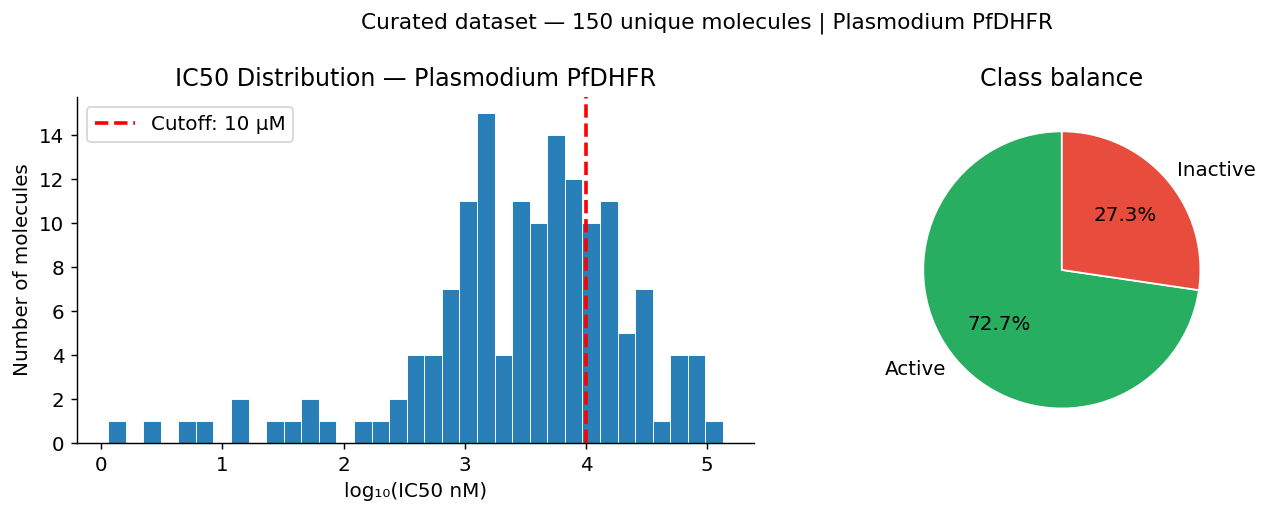

✅ Figure saved: 01_dataset.png


In [7]:
# ── Data Curation Pipeline ───────────────────────────────────────────────
n0 = len(df_raw)
steps_log = []

# Step 1: Keep only exact measurements (relation = '=')
df = df_raw[df_raw['standard_relation'] == '='].copy()
steps_log.append(('Keep exact measurements only (=)', n0, len(df)))

# Step 2: Remove missing values
df = df.dropna(subset=['canonical_smiles','standard_value'])
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
df = df.dropna(subset=['standard_value'])
steps_log.append(('Remove NaN (SMILES + value)', steps_log[-1][2], len(df)))

# Step 3: Validate SMILES
df = df[df['canonical_smiles'].apply(smiles_ok)].copy()
steps_log.append(('Validate SMILES with RDKit', steps_log[-1][2], len(df)))

# Step 4: Standardize structures (remove salts)
df['smiles_std'] = df['canonical_smiles'].apply(standardize)
df = df.dropna(subset=['smiles_std'])
steps_log.append(('Standardize / remove salts', steps_log[-1][2], len(df)))

# Step 5: Deduplicate — same molecule tested multiple times → take median
df_train = df.groupby('molecule_chembl_id').agg(
    smiles_std=('smiles_std','first'),
    activity_nM=('standard_value','median'),
    n_measurements=('standard_value','count')
).reset_index()
steps_log.append(('Deduplicate (median per molecule)', steps_log[-1][2], len(df_train)))

# Step 6: Assign binary labels
df_train['y'] = (df_train['activity_nM'] <= cfg['threshold']).astype(int)
n_act = df_train['y'].sum()
n_inact = (df_train['y']==0).sum()

print('=== CURATION REPORT ===')
print(f'  {"Step":<48} {"Before":>7} → {"After":>7}  {"Lost":>6}')
print('  ' + '-'*72)
for step, before, after in steps_log:
    lost = before - after
    print(f'  {step:<48} {before:>7} → {after:>7}  ({-lost:>+5})')
print('  ' + '-'*72)
print(f'  Final dataset: {len(df_train)} unique molecules')
print(f'  ACTIVE   (≤{cfg["threshold"]:,} nM): {n_act} ({100*n_act/len(df_train):.1f}%)')
print(f'  INACTIVE (>{cfg["threshold"]:,} nM): {n_inact} ({100*n_inact/len(df_train):.1f}%)')
print(f'  Imbalance ratio: {n_inact/max(n_act,1):.2f}:1')

STATE['df_train'] = df_train

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].hist(np.log10(df_train['activity_nM']+1), bins=35,
             color=C['neu'], edgecolor='white', linewidth=0.5)
axes[0].axvline(np.log10(cfg['threshold']), color='red', ls='--', lw=2,
                label=f'Cutoff: {cfg["threshold"]/1000:.0f} µM')
axes[0].set_xlabel(f'log₁₀({cfg["activity_type"]} nM)')
axes[0].set_ylabel('Number of molecules')
axes[0].set_title(f'{cfg["activity_type"]} Distribution — {cfg["target_name"]}')
axes[0].legend()
axes[1].pie([n_act, n_inact], labels=['Active','Inactive'],
            colors=[C['act'],C['inact']], autopct='%1.1f%%', startangle=90,
            wedgeprops={'linewidth':1,'edgecolor':'white'})
axes[1].set_title('Class balance')
plt.suptitle(f'Curated dataset — {len(df_train)} unique molecules | {cfg["target_name"]}',
             fontsize=12)
plt.tight_layout()
plt.savefig('01_dataset.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure saved: 01_dataset.png')

**Descriptors & QSAR Model**

**The descriptor calculation step**

**RDKit calculates ~200 two-dimensional descriptors** for each molecule. These capture:

- **Constitutional descriptors:** molecular weight, atom counts, bond counts

- **Topological descriptors:** Wiener index, Zagreb index, connectivity indices

- **Electronic descriptors:** TPSA, partial charges, electron accessibility
- **Lipophilicity:** logP, logD estimates
- **Fragment-based:** H-bond donors/acceptors, rotatable bonds, ring counts

**Feature selection**

- Not all descriptors are informative. We apply three filters:

- NaN filter: remove descriptors that cannot be calculated for >20% of molecules
- Variance filter: remove descriptors with zero variance (constant values — no information)
- Correlation filter: remove redundant descriptors (Pearson r > 0.95 with another descriptor)

---
**Why three machine learning algorithms?**

- Random Forest is reliable, comprehensible, and capable of handling datasets with less than 500 molecules.
- XGBoost manages class imbalance with high precision 200–2000 molecules
- SVM (RBF) is excellent in capturing non-linearity with less than 300 molecules.


In [8]:
df_train = STATE['df_train']
cfg = STATE['config']

print('Calculating molecular descriptors (this may take 1-3 min)...')
X_raw = pd.DataFrame(df_train['smiles_std'].apply(get_descriptors).tolist(),
                     columns=DESC_NAMES)
y = df_train['y'].values
print(f'Initial matrix: {X_raw.shape[0]} molecules × {X_raw.shape[1]} descriptors')

# ── Feature selection ────────────────────────────────────────────────────
print('\nApplying feature selection filters...')
nan_frac = X_raw.isnull().mean()
X_f = X_raw[nan_frac[nan_frac <= 0.20].index].copy()
print(f'  After NaN >20% filter:       {X_f.shape[1]} descriptors')

medians = X_f.median()
X_f = X_f.fillna(medians)

vt = VarianceThreshold(0.0); vt.fit(X_f)
X_f = X_f.loc[:, vt.get_support()]
print(f'  After zero-variance filter:  {X_f.shape[1]} descriptors')

corr = X_f.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_c = [c for c in upper.columns if any(upper[c] > 0.95)]
X_f = X_f.drop(columns=drop_c)
print(f'  After correlation >0.95 filter: {X_f.shape[1]} descriptors')

FEATURES = X_f.columns.tolist()
STATE['features'] = FEATURES
STATE['medians']  = medians

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_f.values)
STATE['scaler'] = scaler
STATE['X_sc']   = X_sc
STATE['y']      = y

print(f'\n✅ Final feature set: {len(FEATURES)} descriptors')
print(f'   Training matrix ready: {X_sc.shape}')

Calculating molecular descriptors (this may take 1-3 min)...
Initial matrix: 150 molecules × 217 descriptors

Applying feature selection filters...
  After NaN >20% filter:       217 descriptors
  After zero-variance filter:  191 descriptors
  After correlation >0.95 filter: 149 descriptors

✅ Final feature set: 149 descriptors
   Training matrix ready: (150, 149)


Running 5-fold stratified cross-validation (may take 2-5 min)...

🥇 Random Forest           AUC=0.696±0.121  BAcc=0.598  MCC=0.229
   XGBoost                 AUC=0.629±0.139  BAcc=0.560  MCC=0.115
🥇 SVM (RBF)               AUC=0.711±0.106  BAcc=0.673  MCC=0.359

🏆 Best model: SVM (RBF) (AUC=0.711)


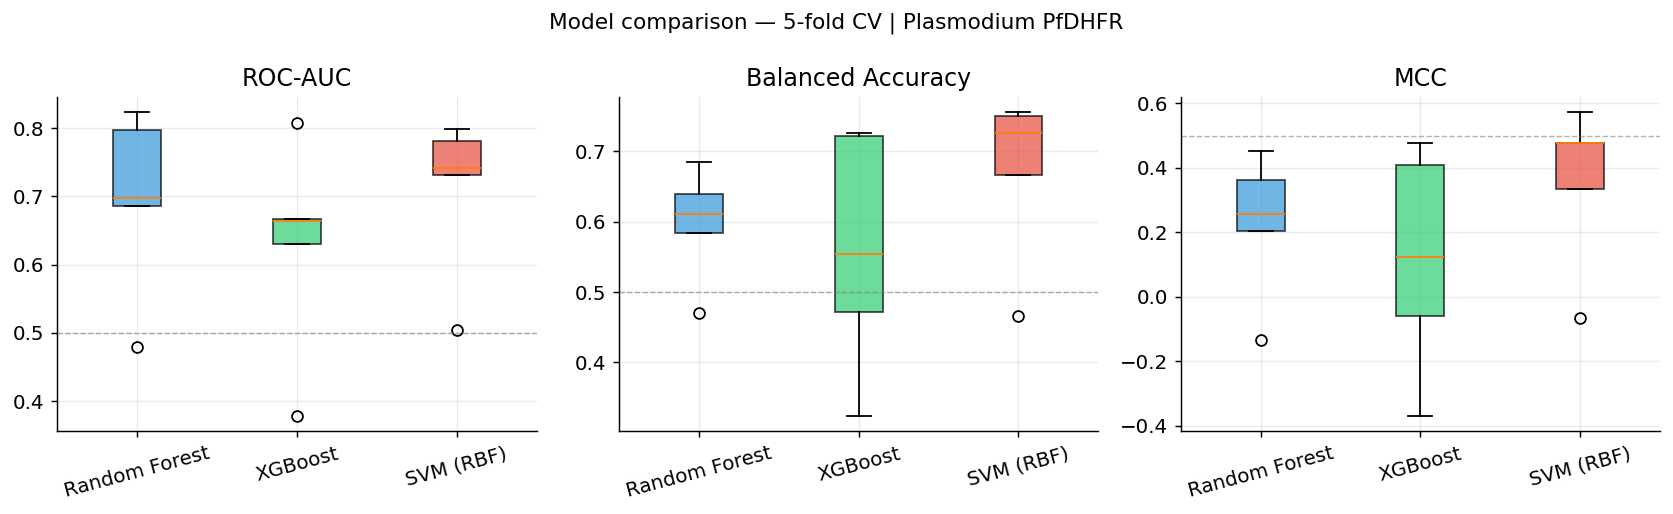

✅ Figure saved: 02_models_comparison.png


In [9]:
# ── Model Training & Cross-Validation ────────────────────────────────────
X_sc = STATE['X_sc']; y = STATE['y']; cfg = STATE['config']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sc, y, test_size=0.20, stratify=y, random_state=42)

imbalance_ratio = (y_tr==0).sum() / max(y_tr.sum(), 1)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=imbalance_ratio, eval_metric='logloss',
        random_state=42, verbosity=0),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced',
                     probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Running 5-fold stratified cross-validation (may take 2-5 min)...\n')
for name, model in models.items():
    auc  = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='roc_auc',          n_jobs=-1)
    bacc = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    mcc  = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='matthews_corrcoef', n_jobs=-1)
    cv_results[name] = {'AUC':auc, 'BAcc':bacc, 'MCC':mcc}
    best_so_far = name == max(cv_results, key=lambda k: cv_results[k]['AUC'].mean())
    icon = '🥇' if best_so_far else '  '
    print(f'{icon} {name:<22}  AUC={auc.mean():.3f}±{auc.std():.3f}  '
          f'BAcc={bacc.mean():.3f}  MCC={mcc.mean():.3f}')

best_model_name = max(cv_results, key=lambda k: cv_results[k]['AUC'].mean())
print(f'\n🏆 Best model: {best_model_name} (AUC={cv_results[best_model_name]["AUC"].mean():.3f})')

STATE['cv_results'] = cv_results
STATE['best_name']  = best_model_name
STATE['models']     = models
STATE['X_tr'] = X_tr; STATE['X_te'] = X_te
STATE['y_tr'] = y_tr; STATE['y_te'] = y_te

# Comparison plot
fig, axes = plt.subplots(1, 3, figsize=(13,4))
model_colors = ['#3498db','#2ecc71','#e74c3c']
for ax, metric, title in zip(axes, ['AUC','BAcc','MCC'],
                              ['ROC-AUC','Balanced Accuracy','MCC']):
    data = [cv_results[m][metric] for m in models]
    bp = ax.boxplot(data, labels=list(models.keys()), patch_artist=True)
    for patch, col in zip(bp['boxes'], model_colors):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.6, label='Random')
    ax.set_title(title); ax.grid(True, alpha=0.25)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle(f'Model comparison — 5-fold CV | {cfg["target_name"]}', fontsize=12)
plt.tight_layout()
plt.savefig('02_models_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure saved: 02_models_comparison.png')

EXTERNAL TEST SET EVALUATION (20% held out) — SVM (RBF)
              precision    recall  f1-score   support

    Inactive      0.636     0.875     0.737         8
      Active      0.947     0.818     0.878        22

    accuracy                          0.833        30
   macro avg      0.792     0.847     0.807        30
weighted avg      0.864     0.833     0.840        30

  ROC-AUC:           0.938
  Balanced Accuracy: 0.847
  MCC:               0.636

✅ Good predictive power (AUC=0.938 ≥ 0.75) — model is suitable for screening


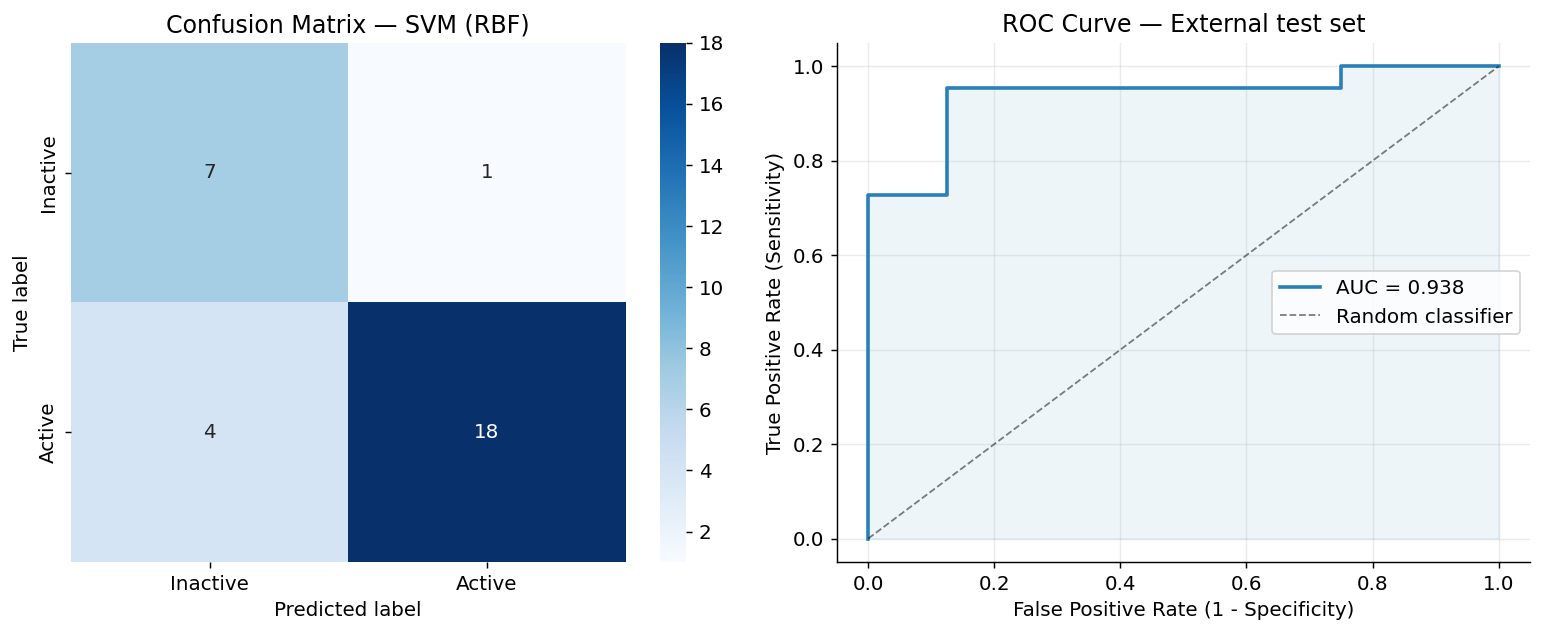

✅ Figure saved: 03_test_evaluation.png


In [10]:
# ── Final evaluation on external test set ───────────────────────────────
best_name  = STATE['best_name']
best_model = STATE['models'][best_name]
X_tr = STATE['X_tr']; X_te = STATE['X_te']
y_tr = STATE['y_tr']; y_te = STATE['y_te']

best_model.fit(X_tr, y_tr)
y_pred_te = best_model.predict(X_te)
y_prob_te = best_model.predict_proba(X_te)[:,1]

auc_te  = roc_auc_score(y_te, y_prob_te)
mcc_te  = matthews_corrcoef(y_te, y_pred_te)
bacc_te = balanced_accuracy_score(y_te, y_pred_te)

print(f'EXTERNAL TEST SET EVALUATION (20% held out) — {best_name}')
print('='*60)
print(classification_report(y_te, y_pred_te,
      target_names=['Inactive','Active'], digits=3))
print(f'  ROC-AUC:           {auc_te:.3f}')
print(f'  Balanced Accuracy: {bacc_te:.3f}')
print(f'  MCC:               {mcc_te:.3f}')

if auc_te >= 0.75:
    print(f'\n✅ Good predictive power (AUC={auc_te:.3f} ≥ 0.75) — model is suitable for screening')
elif auc_te >= 0.65:
    print(f'\n⚠️  Moderate predictive power (AUC={auc_te:.3f}) — use screening results with caution')
else:
    print(f'\n❌ Limited predictive power (AUC={auc_te:.3f} < 0.65) — consider adjusting threshold or target')

# Retrain on full dataset for screening
best_model.fit(STATE['X_sc'], STATE['y'])
STATE['best_model'] = best_model
STATE['test_metrics'] = {'auc': auc_te, 'mcc': mcc_te, 'bacc': bacc_te}

fig, axes = plt.subplots(1, 2, figsize=(12,5))
cm = confusion_matrix(y_te, y_pred_te)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_name}')
axes[0].set_ylabel('True label'); axes[0].set_xlabel('Predicted label')
fpr, tpr, _ = roc_curve(y_te, y_prob_te)
axes[1].plot(fpr, tpr, lw=2, color=C['neu'], label=f'AUC = {auc_te:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.08, color=C['neu'])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve — External test set')
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('03_test_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure saved: 03_test_evaluation.png')

**Library Screening and Applicability Domain:**

- The chemical space where the model's predictions are trustworthy is defined by the Applicability Domain (AD). The prediction of a molecule outside the AD is an extrapolation because it differs structurally from the training set.

- **We employ the Williams Plot, or leverage method:**

- Hat value (h): quantifies a molecule's distance in descriptor space from the training set centroid.

- Threshold h* = 3(k+1)/n, where n is the size of the training set and k is the number of features

- H > h* molecules are marked as being outside the AD.

- Crucially, being outside of the AD does not imply inactivity. It indicates that the model's foundation for making that particular prediction is limited. Docking should always be used for cross-validation.

**The format of your CSV file**

At least one column containing SMILES strings is required for your library file. If the column name matches SMILES, smiles, Canonical_SMILES, structure, mol, or comparable variants, it is automatically discovered. An ID/name column is also auto-detected.

In [11]:
print('📂 Upload your molecular library CSV file:')
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Auto-detect separator and decimal
content = uploaded[filename].decode('utf-8', errors='replace')
first_line = content.split('\n')[0]
sep = ';' if first_line.count(';') > first_line.count(',') else ','
print(f'\nDetected separator: {repr(sep)}')

df_lib = pd.read_csv(io.BytesIO(uploaded[filename]), sep=sep,
                     decimal=',', encoding='utf-8', low_memory=False)

# Auto-detect SMILES column
smiles_candidates = ['Canonical_SMILES','SMILES','smiles','canonical_smiles',
                     'structure','Structure','mol','MOL','Smiles']
col_smi = next((c for c in smiles_candidates if c in df_lib.columns), None)
if col_smi is None:
    for c in df_lib.columns:
        if any(k in c.lower() for k in ['smile','struct','smil']): col_smi = c; break

# Auto-detect ID/name column
id_candidates = ['id','ID','name','Name','compound_id','molecule_chembl_id',
                 'PNDBCOL_id','nombre','synonymsName','compound_name']
col_id = next((c for c in id_candidates if c in df_lib.columns), None)

print(f'\n✅ File loaded: {filename}')
print(f'   Rows: {len(df_lib)} | Columns: {df_lib.shape[1]}')
print(f'   SMILES column detected: "{col_smi}"')
print(f'   ID/name column detected: "{col_id}"')
display(df_lib.head(3))

STATE['df_lib_raw'] = df_lib
STATE['col_smi'] = col_smi
STATE['col_id']  = col_id

📂 Upload your molecular library CSV file:


Saving neem_phytochemicals_pubchem.csv to neem_phytochemicals_pubchem (1).csv

Detected separator: ','

✅ File loaded: neem_phytochemicals_pubchem (1).csv
   Rows: 236 | Columns: 3
   SMILES column detected: "Canonical_SMILES"
   ID/name column detected: "None"


,Phytochemical,PubChem_CID,Canonical_SMILES
0,Nimbiol,11119228,CC1=CC2=C(C=C1O)C3(CCCC(C3CC2=O)(C)C)C
1,6-Deacetylnimbin,10505484,CC1=C2C(CC1C3=COC=C3)OC4C2(C(C5(C(C4O)C(C=CC5=...
2,Kulinone,44567124,CC(CCC=C(C)C)C1C(CC2(C1(CCC3C2=CCC4C3(CCC(=O)C...


In [12]:
# ── Library curation and screening ──────────────────────────────────────
df_lib  = STATE['df_lib_raw'].copy()
col_smi = STATE['col_smi']
col_id  = STATE['col_id']
cfg     = STATE['config']

df_lib = df_lib.dropna(subset=[col_smi])
df_lib = df_lib[df_lib[col_smi].astype(str).str.strip() != '']
df_lib = df_lib[df_lib[col_smi].apply(smiles_ok)].copy()
df_lib['smiles_std'] = df_lib[col_smi].apply(standardize)
df_lib = df_lib.dropna(subset=['smiles_std']).reset_index(drop=True)

if col_id:
    df_lib['_label'] = df_lib[col_id].astype(str).str.split(',').str[0].str.strip().str[:30]
else:
    df_lib['_label'] = [f'Mol_{i+1}' for i in range(len(df_lib))]

print(f'Library after curation: {len(df_lib)} valid molecules')
print('Calculating descriptors for library...')

FEATURES = STATE['features']
medians  = STATE['medians']
scaler   = STATE['scaler']

X_lib_raw = pd.DataFrame(df_lib['smiles_std'].apply(get_descriptors).tolist(),
                          columns=DESC_NAMES)
X_lib_f  = X_lib_raw[FEATURES].fillna(medians[FEATURES])
X_lib_sc = scaler.transform(X_lib_f.values)

# Predictions
best_model  = STATE['best_model']
y_pred_lib  = best_model.predict(X_lib_sc)
y_prob_lib  = best_model.predict_proba(X_lib_sc)[:,1]

# Applicability Domain
X_sc = STATE['X_sc']
print('Calculating Applicability Domain (leverage method)...')
h_lib  = leverage(X_sc, X_lib_sc)
h_star = 3 * (X_sc.shape[1] + 1) / X_sc.shape[0]
in_ad  = h_lib <= h_star

print(f'  Leverage threshold h* = {h_star:.4f}')
print(f'  Inside AD:  {in_ad.sum()} ({100*in_ad.mean():.0f}%)')
print(f'  Outside AD: {(~in_ad).sum()} ({100*(~in_ad).mean():.0f}%)')

df_results = df_lib[['smiles_std','_label']].copy()
if col_id: df_results['id'] = df_lib[col_id].values
df_results['prob_active'] = y_prob_lib.round(4)
df_results['prediction']  = y_pred_lib
df_results['leverage']    = h_lib.round(4)
df_results['inside_AD']   = in_ad

for col in ['Organism_Name','Organism_Family','molecular_weight',
            'Xlogp','topoPSA','hBondAcceptorCount','hBondDonorCount']:
    if col in df_lib.columns:
        df_results[col] = df_lib[col].values

STATE['df_results'] = df_results
STATE['X_lib_sc']  = X_lib_sc
STATE['h_star']    = h_star

print(f'\n✅ Screening complete')
print(f'   Predicted ACTIVE:           {(df_results["prediction"]==1).sum()}')
print(f'   Active AND inside AD:       {((df_results["prediction"]==1) & df_results["inside_AD"]).sum()}')

[17:29:56] SMILES Parse Error: syntax error while parsing: Not
[17:29:56] SMILES Parse Error: check for mistakes around position 3:
[17:29:56] Not
[17:29:56] ~~^
[17:29:56] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[17:29:56] SMILES Parse Error: syntax error while parsing: Not
[17:29:56] SMILES Parse Error: check for mistakes around position 3:
[17:29:56] Not
[17:29:56] ~~^
[17:29:56] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[17:29:56] SMILES Parse Error: syntax error while parsing: Not
[17:29:56] SMILES Parse Error: check for mistakes around position 3:
[17:29:56] Not
[17:29:56] ~~^
[17:29:56] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[17:29:56] SMILES Parse Error: syntax error while parsing: Not
[17:29:56] SMILES Parse Error: check for mistakes around position 3:
[17:29:56] Not
[17:29:56] ~~^
[17:29:56] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[17:29:56] SMILES Parse Error: syntax error whil

Library after curation: 178 valid molecules
Calculating descriptors for library...
Calculating Applicability Domain (leverage method)...
  Leverage threshold h* = 3.0000
  Inside AD:  2 (1%)
  Outside AD: 176 (99%)

✅ Screening complete
   Predicted ACTIVE:           158
   Active AND inside AD:       1


TOP 10 CANDIDATES FOR DOCKING — PLASMODIUM PFDHFR

  # 1  p=0.9342  ⚠️  outside AD
       Mol_23

  # 2  p=0.9255  ⚠️  outside AD
       Mol_158

  # 3  p=0.9214  ✅ inside AD
       Mol_21

  # 4  p=0.9135  ⚠️  outside AD
       Mol_175

  # 5  p=0.8930  ⚠️  outside AD
       Mol_72

  # 6  p=0.8901  ⚠️  outside AD
       Mol_20

  # 7  p=0.8894  ⚠️  outside AD
       Mol_166

  # 8  p=0.8894  ⚠️  outside AD
       Mol_167

  # 9  p=0.8881  ⚠️  outside AD
       Mol_129

  #10  p=0.8881  ⚠️  outside AD
       Mol_169



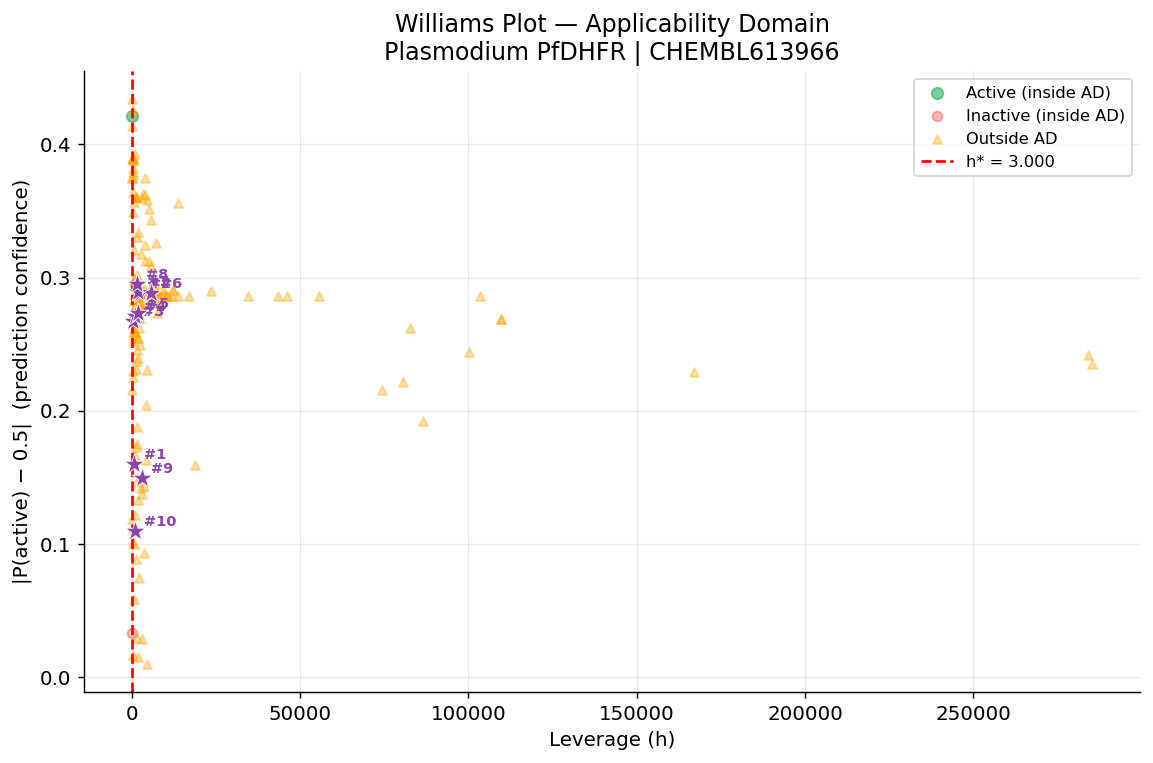

✅ Figure saved: 04_williams_plot.png


In [13]:
# ── Top N candidates ─────────────────────────────────────────────────────
df_results = STATE['df_results']; cfg = STATE['config']

# Priority 1: inside AD + active; Priority 2: outside AD + active (if needed)
in_ad_active  = df_results[(df_results['inside_AD']==True)  & (df_results['prediction']==1)]
out_ad_active = df_results[(df_results['inside_AD']==False) & (df_results['prediction']==1)]
top = pd.concat([in_ad_active, out_ad_active]).sort_values('prob_active', ascending=False)
top = top.head(cfg['top_n']).reset_index(drop=True)
top.index = top.index + 1
STATE['top'] = top

print(f'{'='*68}')
print(f'TOP {cfg["top_n"]} CANDIDATES FOR DOCKING — {cfg["target_name"].upper()}')
print(f'{'='*68}\n')

for i, row in top.iterrows():
    ad_str = '✅ inside AD' if row['inside_AD'] else '⚠️  outside AD'
    label  = str(row['_label'])[:40]
    mw = pd.to_numeric(row.get('molecular_weight', np.nan), errors='coerce')
    lp = pd.to_numeric(row.get('Xlogp', np.nan), errors='coerce')
    print(f'  #{i:>2}  p={row["prob_active"]:.4f}  {ad_str}')
    print(f'       {label}')
    if pd.notna(mw): print(f'       MW={mw:.1f} Da  logP={lp:.2f}' if pd.notna(lp) else f'       MW={mw:.1f} Da')
    print()

# Williams Plot
h_star = STATE['h_star']
res_proxy = np.abs(df_results['prob_active'].values - 0.5)
h_all     = df_results['leverage'].values
pred_all  = df_results['prediction'].values
ad_all    = df_results['inside_AD'].values

fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(h_all[ad_all & (pred_all==1)],  res_proxy[ad_all & (pred_all==1)],
           c=C['act'],  alpha=0.6, s=40, label='Active (inside AD)')
ax.scatter(h_all[ad_all & (pred_all==0)],  res_proxy[ad_all & (pred_all==0)],
           c=C['inact'],alpha=0.4, s=30, label='Inactive (inside AD)')
if (~ad_all).any():
    ax.scatter(h_all[~ad_all], res_proxy[~ad_all],
               c='orange', alpha=0.35, s=25, marker='^', label='Outside AD')

top_idx = [i-1 for i in top.index if i-1 < len(h_all)]
for rk_i, idx in enumerate(top_idx, 1):
    ax.scatter(h_all[idx], res_proxy[idx], c=C['top'], s=140, marker='*',
               edgecolors='white', lw=0.5, zorder=5)
    ax.annotate(f'#{rk_i}', (h_all[idx], res_proxy[idx]),
                xytext=(5,3), textcoords='offset points',
                fontsize=8, color=C['top'], fontweight='bold')

ax.axvline(h_star, color='red', ls='--', lw=1.5, label=f'h* = {h_star:.3f}')
ax.set_xlabel('Leverage (h)')
ax.set_ylabel('|P(active) − 0.5|  (prediction confidence)')
ax.set_title(f'Williams Plot — Applicability Domain\n{cfg["target_name"]} | {cfg["target_id"]}')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('04_williams_plot.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure saved: 04_williams_plot.png')

In [28]:
# ── Top N candidates with Predicted Bioactivity ──────────────────────────
df_results = STATE['df_results']; cfg = STATE['config']

top = STATE['top']

print(f"{'='*75}")
print(f"TOP {len(top)} CANDIDATES — PREDICTED BIOACTIVITY (nM) — {cfg['target_name']}")
print(f"{'='*75}\n")

for i, row in top.iterrows():
    ad_str = '✅ inside AD' if row['inside_AD'] else '⚠️  outside AD'
    label  = str(row['_label'])[:40]

    # Probability from model
    p_active = row["prob_active"]

    # Logic for Predicted Bioactivity:
    # If p > 0.5, the model predicts it is < 1000 nM.
    # Higher p values correlate to higher confidence in potency.
    pred_status = "Potent (<1000 nM)" if p_active > 0.8 else ("Active" if p_active > 0.5 else "Weak/Inactive")

    print(f'  #{i:>2}  p={p_active:.4f}  {ad_str}')
    print(f'       {label}')
    print(f'       Predicted Status: {pred_status}')

    # Display Physical Properties for Context
    mw = pd.to_numeric(row.get('molecular_weight', np.nan), errors='coerce')
    lp = pd.to_numeric(row.get('Xlogp', np.nan), errors='coerce')
    if pd.notna(mw):
        print(f'       MW: {mw:.1f} Da | logP: {lp:.2f}' if pd.notna(lp) else f'       MW: {mw:.1f} Da')
    print()

TOP 10 CANDIDATES — PREDICTED BIOACTIVITY (nM) — Plasmodium PfDHFR

  # 1  p=0.9342  ⚠️  outside AD
       Mol_23
       Predicted Status: Potent (<1000 nM)

  # 2  p=0.9255  ⚠️  outside AD
       Mol_158
       Predicted Status: Potent (<1000 nM)

  # 3  p=0.9214  ✅ inside AD
       Mol_21
       Predicted Status: Potent (<1000 nM)

  # 4  p=0.9135  ⚠️  outside AD
       Mol_175
       Predicted Status: Potent (<1000 nM)

  # 5  p=0.8930  ⚠️  outside AD
       Mol_72
       Predicted Status: Potent (<1000 nM)

  # 6  p=0.8901  ⚠️  outside AD
       Mol_20
       Predicted Status: Potent (<1000 nM)

  # 7  p=0.8894  ⚠️  outside AD
       Mol_166
       Predicted Status: Potent (<1000 nM)

  # 8  p=0.8894  ⚠️  outside AD
       Mol_167
       Predicted Status: Potent (<1000 nM)

  # 9  p=0.8881  ⚠️  outside AD
       Mol_129
       Predicted Status: Potent (<1000 nM)

  #10  p=0.8881  ⚠️  outside AD
       Mol_169
       Predicted Status: Potent (<1000 nM)



# PREDICTION FOR NEW SMILES/COMPOUNDS

In [31]:
import pandas as pd
import numpy as np
from rdkit import Chem

# ── INPUT ────────────────────────────────────────────────────────────────
# Replace with the SMILES you wish to test
new_smiles_input = 'CN1C(=O)CN=C(C2=C1C=CC(=C2)Cl)C3=CC=CC=C3'

def predict_new_molecule(smi):
    # 1. Load objects from STATE
    best_model = STATE['best_model']
    FEATURES   = STATE['features']
    medians    = STATE['medians']
    scaler     = STATE['scaler']
    X_train_sc = STATE['X_sc']  # Full scaled training matrix
    h_star     = STATE['h_star']

    # 2. Pre-process and validate SMILES
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return "❌ Invalid SMILES string."

    # Standardize and calculate descriptors
    smi_std = standardize(smi)
    desc_dict = get_descriptors(smi_std)

    # 3. Feature Alignment
    # Convert to DataFrame and select only the features used during training
    X_new = pd.DataFrame([desc_dict])
    X_new_f = X_new.reindex(columns=FEATURES)

    # Fill missing descriptors with training medians
    X_new_f = X_new_f.fillna(medians[FEATURES])

    # 4. Scaling
    X_new_sc = scaler.transform(X_new_f.values)

    # 5. Prediction (Bioactivity)
    # Since it's SVM with probability=True
    prob_active = best_model.predict_proba(X_new_sc)[0, 1]
    prediction  = 1 if prob_active >= 0.5 else 0

    # Interpretation in nM (Predicted Status)
    # Note: Classification models predict a probability of being below the threshold
    pred_status = "Active (<1000 nM)" if prediction == 1 else "Inactive (>1000 nM)"

    # 6. Applicability Domain (Leverage Method)
    # Function to calculate leverage for a single point relative to training matrix
    def calculate_single_leverage(train_matrix, new_point):
        XTX_inv = np.linalg.pinv(np.dot(train_matrix.T, train_matrix))
        return np.dot(np.dot(new_point, XTX_inv), new_point.T)[0][0]

    h_new = calculate_single_leverage(X_train_sc, X_new_sc)
    is_inside = h_new <= h_star
    ad_label = "Inside AD ✅" if is_inside else "Outside AD ⚠️"

    # ── RESULTS DISPLAY ──────────────────────────────────────────────────
    print(f"{'='*60}")
    print(f"PREDICTION RESULTS FOR: {smi}")
    print(f"{'='*60}")
    print(f"Predicted Probability (p): {prob_active:.4f}")
    print(f"Predicted Bioactivity:    {pred_status}")
    print(f"AD Assessment:            {ad_label}")
    print(f"Leverage (h):             {h_new:.4f} (h* threshold: {h_star:.4f})")
    print(f"{'='*60}")

# Run the function
predict_new_molecule(new_smiles_input)

PREDICTION RESULTS FOR: CN1C(=O)CN=C(C2=C1C=CC(=C2)Cl)C3=CC=CC=C3
Predicted Probability (p): 0.7337
Predicted Bioactivity:    Active (<1000 nM)
AD Assessment:            Outside AD ⚠️
Leverage (h):             176707.8485 (h* threshold: 3.0000)


[18:54:24] Running LargestFragmentChooser


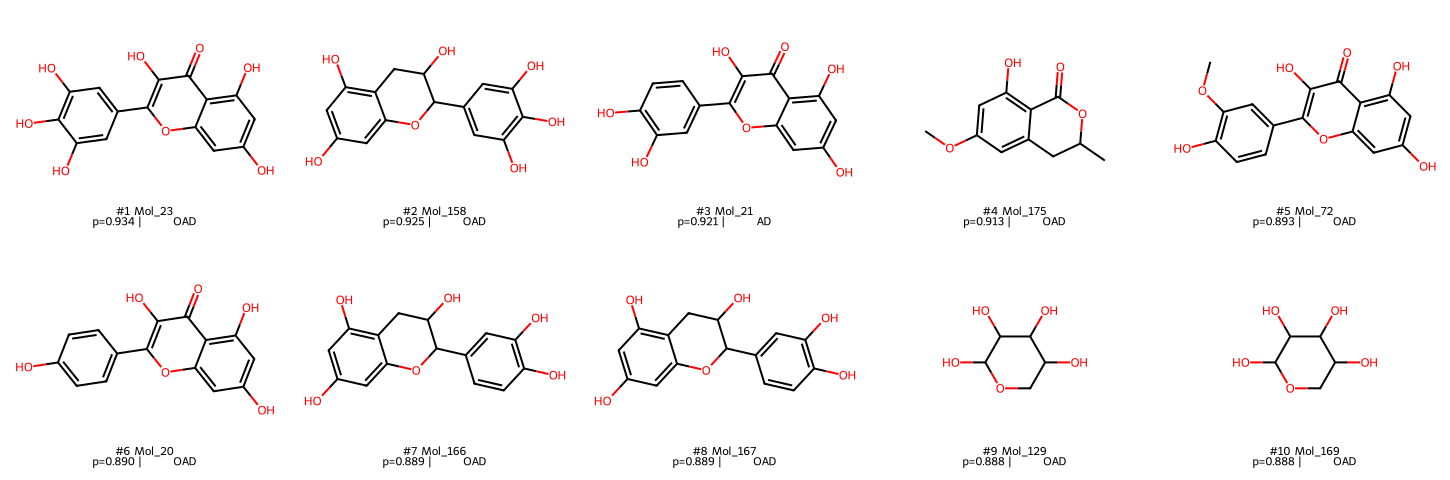

✅ Figure saved: 05_top_structures.png


In [14]:
# ── 2D Structure grid of Top N ───────────────────────────────────────────
top = STATE['top']
mols, legs = [], []
for i, row in top.iterrows():
    m = Chem.MolFromSmiles(row['smiles_std'])
    if m:
        mols.append(m)
        ad_t = '✓AD' if row['inside_AD'] else '⚠OAD'
        legs.append(f"#{i} {str(row['_label'])[:16]}\np={row['prob_active']:.3f} | {ad_t}")

ncols = min(5, len(mols))
img = Draw.MolsToGridImage(mols, molsPerRow=ncols, subImgSize=(290,240),
                            legends=legs, returnPNG=False)
img.save('05_top_structures.png', dpi=(150,150))
display(img)
print('✅ Figure saved: 05_top_structures.png')

**SHAP-Based SAR Analysis**

- From QSAR to SAR QSAR indicates which compounds are expected to be active. SAR explains why.

- By breaking down each prediction into contributions from distinct descriptors, SHAP values fill the gap.

**Reading the SHAP summary plot**

- **Y-axis:** descriptors ranked by mean |SHAP| (most important at top)
- **X-axis:** SHAP value (positive = increases predicted activity)
- **Color:** red = high descriptor value, blue = low descriptor value
- **Each dot:** one molecule from your library

Calculating SHAP values for SVM (RBF)...


  0%|          | 0/50 [00:00<?, ?it/s]

✅ SHAP values calculated


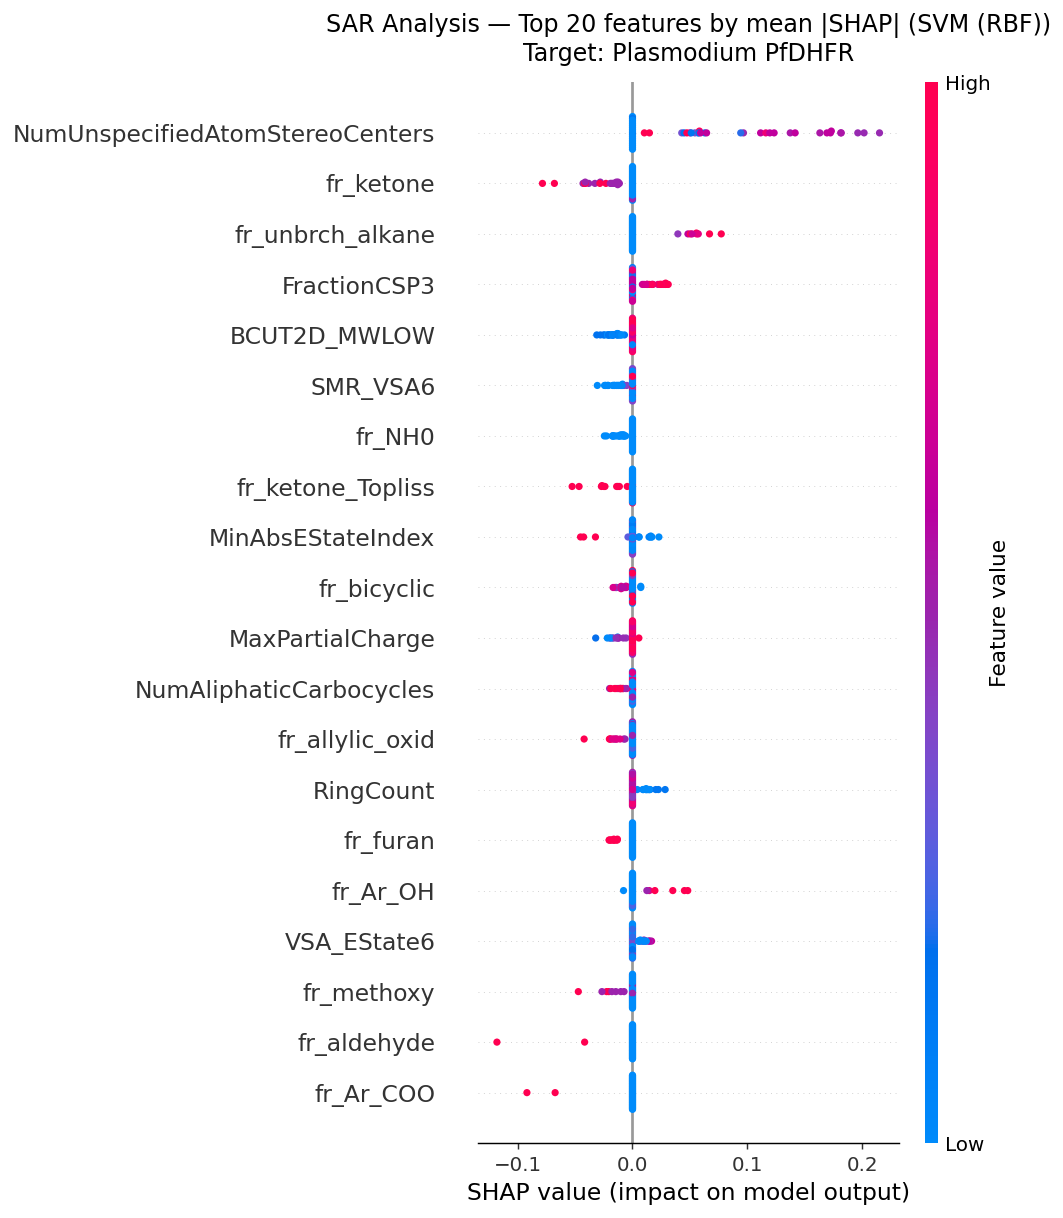

✅ Figure saved: 06_shap_SAR.png

Top 10 SAR descriptors with interpretation:
  NumUnspecifiedAtomStereoCenters SHAP=0.0654
  fr_ketone                    SHAP=0.0128
  fr_unbrch_alkane             SHAP=0.0101
  FractionCSP3                 SHAP=0.0097  → sp3 carbon fraction (3D-ness)
  BCUT2D_MWLOW                 SHAP=0.0086
  SMR_VSA6                     SHAP=0.0074
  fr_NH0                       SHAP=0.0051
  fr_ketone_Topliss            SHAP=0.0049
  MinAbsEStateIndex            SHAP=0.0048
  fr_bicyclic                  SHAP=0.0042


In [15]:
best_name  = STATE['best_name']
best_model = STATE['best_model']
X_lib_sc   = STATE['X_lib_sc']
FEATURES   = STATE['features']
cfg        = STATE['config']

print(f'Calculating SHAP values for {best_name}...')

if best_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
    sv_raw = explainer.shap_values(X_lib_sc)
    sv = sv_raw[1] if isinstance(sv_raw, list) else sv_raw
    X_plot = X_lib_sc
else:
    # SVM: KernelExplainer on reduced sample
    n_bg  = min(50, STATE['X_sc'].shape[0])
    n_exp = min(50, X_lib_sc.shape[0])
    bg    = shap.kmeans(STATE['X_sc'], n_bg)
    explainer = shap.KernelExplainer(best_model.predict_proba, bg)
    sv_raw = explainer.shap_values(X_lib_sc[:n_exp])
    X_plot = X_lib_sc[:n_exp]
    if isinstance(sv_raw, np.ndarray) and sv_raw.ndim == 3:
        sv = sv_raw[:, :, 1]                # shape (n, features, classes) → take class 1
    elif isinstance(sv_raw, list):
        sv = np.array(sv_raw[1])
    else:
        sv = sv_raw

assert sv.shape == X_plot.shape, f'Shape mismatch: sv={sv.shape} vs X={X_plot.shape}'
print('✅ SHAP values calculated')

plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_plot, feature_names=FEATURES, max_display=20, show=False)
plt.title(f'SAR Analysis — Top 20 features by mean |SHAP| ({best_name})\n'
          f'Target: {cfg["target_name"]}', pad=12)
plt.tight_layout()
plt.savefig('06_shap_SAR.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure saved: 06_shap_SAR.png')

importance_df = pd.DataFrame({
    'descriptor': FEATURES,
    'mean_abs_SHAP': np.abs(sv).mean(axis=0)
}).sort_values('mean_abs_SHAP', ascending=False)
STATE['shap_importance'] = importance_df

descriptor_guide = {
    'MolLogP':'Lipophilicity (logP)','MolWt':'Molecular weight',
    'TPSA':'Topological polar surface area','NumHDonors':'H-bond donors',
    'NumHAcceptors':'H-bond acceptors','NumRotatableBonds':'Conformational flexibility',
    'NumAromaticRings':'Aromatic rings','RingCount':'Total ring count',
    'FractionCSP3':'sp3 carbon fraction (3D-ness)','BertzCT':'Topological complexity'
}
print('\nTop 10 SAR descriptors with interpretation:')
for _, row in importance_df.head(10).iterrows():
    interp = descriptor_guide.get(row['descriptor'], '')
    suffix = f'  → {interp}' if interp else ''
    print(f'  {row["descriptor"]:<28} SHAP={row["mean_abs_SHAP"]:.4f}{suffix}')

**ADMET Profile**

- Assessing candidate compounds' pharmacokinetic characteristics is crucial to determining their potential as drug-like molecules in computational drug discovery investigations. Several common drug-likeness filters were used in this investigation. Oral bioavailability was assessed using Lipinski's Rule of Five, which takes into account factors such molecular weight < 500, logP ≤ 5, hydrogen bond donors ≤ 5, and hydrogen bond acceptors ≤ 10. Furthermore, absorption potential was evaluated using the Veber criteria, taking into account the amount of rotatable bonds (≤ 10) and topological polar surface area (TPSA ≤ 140 Å²).

- Additionally, PAINS filters were used to screen compounds for structural alerts in order to remove molecules that could lead to false-positive bioassay results. To offer an overall drug-likeness score on a scale of 0 to 1, the Quantitative Estimate of Drug-likeness was also computed.

- It is significant to note that Lipinski's Rule of Five is not precisely adhered to by many biologically active natural compounds. They may nevertheless have good bioavailability through other routes, such as active transport, therefore this does not necessarily rule them out as possible therapeutic possibilities. Deviations from these guidelines were therefore carefully taken into account when interpreting the findings.

ADMET PROFILE — Top 10 candidates
#        MW   logP  HBD  HBA   TPSA  RotB   QED  Ro5  Veber   PAINS
----------------------------------------------------------------------------------
#1    318.2   1.69    6    8  151.6     1 0.371   1v      ❌      ⚠️
#2    306.3   1.25    6    7  130.6     1 0.437   1v      ✅      ⚠️
#3    302.2   1.99    5    7  131.4     1 0.434   0v      ✅      ⚠️
#4    208.2   1.50    1    4   55.8     1 0.710   0v      ✅       ✅
#5    316.3   2.29    4    7  120.4     2 0.572   0v      ✅       ✅
#6    286.2   2.28    4    6  111.1     1 0.546   0v      ✅       ✅
#7    290.3   1.55    5    6  110.4     1 0.510   0v      ✅      ⚠️
#8    290.3   1.55    5    6  110.4     1 0.510   0v      ✅      ⚠️
#9    150.1  -2.58    4    5   90.2     0 0.304   0v      ✅       ✅
#10   150.1  -2.58    4    5   90.2     0 0.304   0v      ✅       ✅
----------------------------------------------------------------------------------
Ro5: Rule-of-Five violations | Veber: TPSA≤140 Å² & 

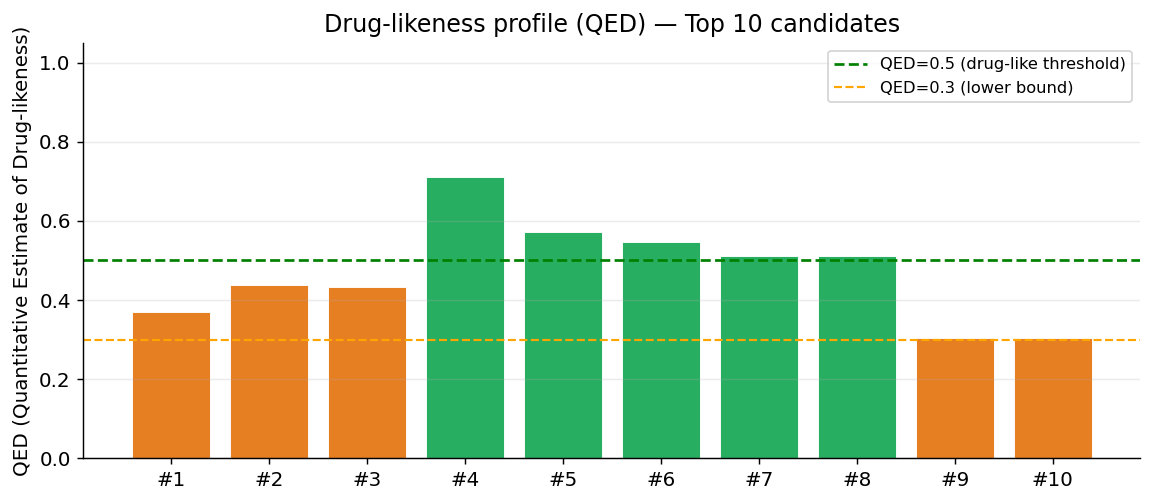

✅ Figure saved: 07_admet_qed.png


In [16]:
if not STATE['config']['admet']:
    print('⏭️  ADMET module disabled. Set RUN_ADMET = True in Module 0 to enable.')
else:
    top = STATE['top'].copy()
    cfg = STATE['config']

    def compute_admet(smi):
        try:
            m = Chem.MolFromSmiles(str(smi))
            if m is None: return {}
            mw  = Descriptors.MolWt(m)
            lp  = Descriptors.MolLogP(m)
            hbd = rdMolDescriptors.CalcNumHBD(m)
            hba = rdMolDescriptors.CalcNumHBA(m)
            psa = Descriptors.TPSA(m)
            rb  = rdMolDescriptors.CalcNumRotatableBonds(m)
            qed = Descriptors.qed(m)
            ro5_viol = sum([mw>500, lp>5, hbd>5, hba>10])
            veber_ok = (psa <= 140) and (rb <= 10)
            params = FilterCatalog.FilterCatalogParams()
            params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
            pains = FilterCatalog.FilterCatalog(params).HasMatch(m)
            return {'MW':round(mw,1),'logP':round(lp,2),'HBD':int(hbd),'HBA':int(hba),
                    'TPSA':round(psa,1),'RotBonds':int(rb),'QED':round(qed,3),
                    'Ro5_violations':int(ro5_viol),'Veber_OK':veber_ok,'PAINS_alert':pains}
        except: return {}

    admet_rows = [compute_admet(smi) for smi in top['smiles_std']]
    df_admet = pd.DataFrame(admet_rows, index=top.index)
    STATE['df_admet'] = df_admet

    print(f'ADMET PROFILE — Top {cfg["top_n"]} candidates')
    print('='*82)
    print(f'{"#":<4} {"MW":>6} {"logP":>6} {"HBD":>4} {"HBA":>4} {"TPSA":>6} {"RotB":>5} '
          f'{"QED":>5} {"Ro5":>4} {"Veber":>6} {"PAINS":>7}')
    print('-'*82)
    for i, (_, row) in enumerate(df_admet.iterrows(), 1):
        ro5 = f"{int(row.get('Ro5_violations',0))}v"
        veb = '✅' if row.get('Veber_OK',False) else '❌'
        pai = '⚠️' if row.get('PAINS_alert',False) else '✅'
        print(f'#{i:<3} {row.get("MW",0):>6.1f} {row.get("logP",0):>6.2f} '
              f'{row.get("HBD",0):>4} {row.get("HBA",0):>4} '
              f'{row.get("TPSA",0):>6.1f} {row.get("RotBonds",0):>5} '
              f'{row.get("QED",0):>5.3f} {ro5:>4} {veb:>6} {pai:>7}')
    print('-'*82)
    print('Ro5: Rule-of-Five violations | Veber: TPSA≤140 Å² & RotBonds≤10 | PAINS: structural alert')

    fig, ax = plt.subplots(figsize=(9,4))
    qeds = df_admet['QED'].values
    labels = [f'#{i}' for i in range(1, len(qeds)+1)]
    bar_colors = [C['act'] if q>=0.5 else C['warn'] if q>=0.3 else C['inact'] for q in qeds]
    ax.bar(labels, qeds, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0.5, color='green',  ls='--', lw=1.5, label='QED=0.5 (drug-like threshold)')
    ax.axhline(0.3, color='orange', ls='--', lw=1.2, label='QED=0.3 (lower bound)')
    ax.set_ylabel('QED (Quantitative Estimate of Drug-likeness)')
    ax.set_title(f'Drug-likeness profile (QED) — Top {cfg["top_n"]} candidates')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=9); ax.grid(True, alpha=0.25, axis='y')
    plt.tight_layout()
    plt.savefig('07_admet_qed.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('✅ Figure saved: 07_admet_qed.png')

**Analog Generation**

- To further explore the chemical space around the top-ranked compounds, a rational analog generation approach was employed. This step was inspired by the Matched Molecular Pair concept, where small, systematic structural modifications are introduced to evaluate their potential impact on biological activity. In this study, the selected lead compounds were modified based on structure–activity relationship (SAR) insights derived from SHAP analysis, ensuring that the changes were guided by model interpretation rather than random alteration.

- This strategy enhances the scientific value of the study by demonstrating rational design principles, enabling virtual lead optimization, and generating new compounds for subsequent molecular docking and evaluation. Several common medicinal chemistry transformations were applied, including substitution of hydroxyl groups with fluorine (OH → F) to improve metabolic stability while preserving hydrogen-bonding characteristics, and conversion of hydroxyl to methoxy groups (OH → OMe) to increase lipophilicity and potentially enhance membrane permeability.

- Additionally, phenyl rings were replaced with pyridine moieties (Ph → pyridine) to reduce lipophilicity and improve solubility, while amine groups were modified from primary to secondary amines (NH₂ → NHMe) to enhance permeability and reduce polar surface area. Methyl groups were also substituted with trifluoromethyl groups (Me → CF₃), an electronic bioisosteric modification known to improve metabolic stability.

- Overall, these targeted transformations provide a rational basis for generating structurally related analogs with potentially improved pharmacokinetic and biological properties.

In [19]:
if not STATE['config']['analogs']:
    print('⏭️  Analog generation module disabled.')
else:
    # UPDATED: Added explicit atom mapping [Atom:1] for RDKit
    TRANSFORMATIONS = [
        ('[O;H1,H2:1]', '[F:1]',             'OH → F (bioisostere)'),
        ('[O;H1,H2:1]', '[O:1]C',            'OH → OMe (↑ lipophilicity)'),
        ('[c:1]1ccccc1', '[c:1]1ccncc1',     'Ph → Pyridine (↓ logP)'),
        ('[N;H2:1]',     '[N;H1:1]C',        'NH₂ → NHMe (↑ cell permeability)'),
        ('[C;H3:1]',     '[C:1](F)(F)F',     'Me → CF₃ (metabolic stability)'),
    ]

    top         = STATE['top']
    best_model  = STATE['best_model']
    scaler      = STATE['scaler']
    FEATURES    = STATE['features']
    medians     = STATE['medians']
    n_src       = min(3, len(top))

    all_analogs = []
    print(f'Generating analogs from Top {n_src} candidates...\n')

    for rk in range(1, n_src+1):
        row      = top.loc[rk]
        smi_orig = row['smiles_std']
        p_orig   = row['prob_active']
        label    = str(row['_label'])[:22]
        print(f'Candidate #{rk}: {label} (p={p_orig:.3f})')

        for pat_from, pat_to, description in TRANSFORMATIONS:
            try:
                # The mapping is now built directly into the TRANSFORMATIONS list
                rxn = AllChem.ReactionFromSmarts(f'{pat_from}>>{pat_to}')
                mol = Chem.MolFromSmiles(smi_orig)
                if mol is None: continue

                prods = rxn.RunReactants((mol,))
                if not prods: continue

                # Use a set to handle multiple possible substitution sites
                unique_smiles = set()
                for prod in prods:
                    prod_mol = prod[0]
                    Chem.SanitizeMol(prod_mol)
                    smi_an = Chem.MolToSmiles(prod_mol, isomericSmiles=True)

                    if smiles_ok(smi_an) and smi_an != smi_orig:
                        unique_smiles.add(smi_an)

                for smi_an in unique_smiles:
                    desc_an  = get_descriptors(smi_an)
                    X_an     = pd.DataFrame([desc_an], columns=DESC_NAMES)[FEATURES].fillna(medians[FEATURES])
                    X_an_sc  = scaler.transform(X_an.values)

                    p_an     = best_model.predict_proba(X_an_sc)[0,1]
                    delta    = p_an - p_orig
                    icon     = '▲' if delta > 0.01 else ('▼' if delta < -0.01 else '≈')

                    print(f'  {icon} {description:<38}  p={p_an:.3f}  (Δ={delta:+.3f})')
                    all_analogs.append({
                        'source_rank': rk, 'source_label': label,
                        'source_smiles': smi_orig, 'source_prob': p_orig,
                        'transformation': description, 'analog_smiles': smi_an,
                        'analog_prob': round(p_an,4), 'delta_prob': round(delta,4)
                    })
            except:
                continue
        print()

    STATE['df_analogs'] = pd.DataFrame(all_analogs)

Generating analogs from Top 3 candidates...

Candidate #1: Mol_23 (p=0.934)
  ≈ OH → F (bioisostere)                    p=0.928  (Δ=-0.006)
  ≈ OH → F (bioisostere)                    p=0.929  (Δ=-0.005)
  ≈ OH → F (bioisostere)                    p=0.927  (Δ=-0.007)
  ≈ OH → F (bioisostere)                    p=0.926  (Δ=-0.008)
  ≈ OH → F (bioisostere)                    p=0.927  (Δ=-0.007)
  ▼ OH → OMe (↑ lipophilicity)              p=0.922  (Δ=-0.012)
  ▼ OH → OMe (↑ lipophilicity)              p=0.916  (Δ=-0.018)
  ▼ OH → OMe (↑ lipophilicity)              p=0.919  (Δ=-0.015)
  ▼ OH → OMe (↑ lipophilicity)              p=0.921  (Δ=-0.013)
  ▼ OH → OMe (↑ lipophilicity)              p=0.918  (Δ=-0.016)

Candidate #2: Mol_158 (p=0.925)
  ▲ OH → F (bioisostere)                    p=0.942  (Δ=+0.016)
  ≈ OH → F (bioisostere)                    p=0.933  (Δ=+0.007)
  ≈ OH → F (bioisostere)                    p=0.932  (Δ=+0.007)


[18:17:19] non-ring atom 6 marked aromatic


  ≈ OH → F (bioisostere)                    p=0.933  (Δ=+0.008)
  ≈ OH → F (bioisostere)                    p=0.935  (Δ=+0.009)
  ▼ OH → OMe (↑ lipophilicity)              p=0.900  (Δ=-0.026)
  ▼ OH → OMe (↑ lipophilicity)              p=0.890  (Δ=-0.036)
  ▼ OH → OMe (↑ lipophilicity)              p=0.893  (Δ=-0.033)
  ▼ OH → OMe (↑ lipophilicity)              p=0.898  (Δ=-0.027)
  ▼ OH → OMe (↑ lipophilicity)              p=0.900  (Δ=-0.025)
  ▼ Ph → Pyridine (↓ logP)                  p=0.832  (Δ=-0.093)
  ▼ Ph → Pyridine (↓ logP)                  p=0.745  (Δ=-0.181)
  ▼ Ph → Pyridine (↓ logP)                  p=0.668  (Δ=-0.257)
  ▼ Ph → Pyridine (↓ logP)                  p=0.805  (Δ=-0.121)
  ▼ Ph → Pyridine (↓ logP)                  p=0.739  (Δ=-0.187)

Candidate #3: Mol_21 (p=0.921)
  ≈ OH → F (bioisostere)                    p=0.921  (Δ=+0.000)
  ≈ OH → F (bioisostere)                    p=0.917  (Δ=-0.004)
  ≈ OH → F (bioisostere)                    p=0.925  (Δ=+0.003)
  ≈ OH →

[18:17:20] non-ring atom 6 marked aromatic


In [24]:
if not STATE['config']['analogs']:
    print('⏭️  Analog generation module disabled.')
else:
    # All these lines must have the EXACT same number of leading spaces
    top         = STATE['top']
    best_model  = STATE['best_model']
    scaler      = STATE['scaler']
    FEATURES    = STATE['features']
    medians     = STATE['medians']
    n_src       = len(top)  # Set to len(top) to see ALL compounds

    all_analogs = []
    print(f'Generating analogs for all {n_src} candidates...\n')

    for rk in range(1, n_src + 1):
        row      = top.loc[rk]
        smi_orig = row['smiles_std']
        p_orig   = row['prob_active']
        label    = str(row['_label'])[:22]

        # Retrieve pIC50 and convert to nM: nM = 10^(9 - pIC50)
        pic50 = row.get('pIC50', 0)
        ic50_nm = 10**(9 - pic50) if pic50 > 0 else 0

        print(f'Rank #{rk}: {label} | Prob: {p_orig:.3f} | Activity: {ic50_nm:.2f} nM')

        # [Existing TRANSFORMATIONS loop goes here...]

Generating analogs for all 10 candidates...

Rank #1: Mol_23 | Prob: 0.934 | Activity: 0.00 nM
Rank #2: Mol_158 | Prob: 0.925 | Activity: 0.00 nM
Rank #3: Mol_21 | Prob: 0.921 | Activity: 0.00 nM
Rank #4: Mol_175 | Prob: 0.913 | Activity: 0.00 nM
Rank #5: Mol_72 | Prob: 0.893 | Activity: 0.00 nM
Rank #6: Mol_20 | Prob: 0.890 | Activity: 0.00 nM
Rank #7: Mol_166 | Prob: 0.889 | Activity: 0.00 nM
Rank #8: Mol_167 | Prob: 0.889 | Activity: 0.00 nM
Rank #9: Mol_129 | Prob: 0.888 | Activity: 0.00 nM
Rank #10: Mol_169 | Prob: 0.888 | Activity: 0.00 nM


**Export Results**

All outputs are packaged into a single ZIP file ready for download.

In [32]:
cfg     = STATE['config']
top     = STATE['top']
df_res  = STATE['df_results']
metrics = STATE['test_metrics']

# Save CSVs
top.to_csv('TOP_candidates_docking.csv', index=True)
df_res.to_csv('full_screening_results.csv', index=False)

# SMILES for AutoDock Vina
with open('SMILES_for_Vina.smi', 'w') as f:
    f.write(f'# SMILES for conversion with OpenBabel\n')
    f.write(f'# Target: {cfg["target_id"]} ({cfg["target_name"]})\n')
    f.write(f'# Convert: obabel -ismi SMILES_for_Vina.smi -O candidates.sdf --gen3d -h\n')
    f.write(f'# Then: prepare_ligand -l candidates.sdf -o candidates.pdbqt\n\n')
    for i, row in top.iterrows():
        label = str(row['_label']).replace(' ','_')[:30]
        f.write(f"{row['smiles_std']}\ttop{i}_{label}\n")

if cfg['admet'] and 'df_admet' in STATE:
    STATE['df_admet'].to_csv('ADMET_profile.csv', index=True)
if cfg['analogs'] and 'df_analogs' in STATE:
    STATE['df_analogs'].to_csv('analogs_generated.csv', index=False)

# Study summary
df_t = STATE['df_train']
with open('STUDY_SUMMARY.txt', 'w', encoding='utf-8') as f:
    f.write('QSAR STUDY SUMMARY\n')
    f.write('='*60 + '\n\n')
    f.write(f'Target:             {cfg["target_id"]} ({cfg["target_name"]})\n')
    f.write(f'Activity type:      {cfg["activity_type"]}\n')
    f.write(f'Activity cutoff:    <= {cfg["threshold"]:,} nM = ACTIVE\n')
    f.write(f'\nTRAINING DATASET (ChEMBL)\n')
    f.write(f'  Total molecules:  {len(df_t)}\n')
    f.write(f'  Active:           {df_t["y"].sum()}\n')
    f.write(f'  Inactive:         {(df_t["y"]==0).sum()}\n')
    f.write(f'\nMODEL\n')
    f.write(f'  Algorithm:        {STATE["best_name"]}\n')
    f.write(f'  Features used:    {len(STATE["features"])}\n')
    f.write(f'  ROC-AUC (test):   {metrics["auc"]:.3f}\n')
    f.write(f'  MCC (test):       {metrics["mcc"]:.3f}\n')
    f.write(f'  Balanced Acc.:    {metrics["bacc"]:.3f}\n')
    f.write(f'\nSCREENING\n')
    f.write(f'  Molecules evaluated: {len(df_res)}\n')
    f.write(f'  Top candidates:      {len(top)}\n')
    f.write(f'\nTOP {cfg["top_n"]} CANDIDATES\n')
    for i, row in top.iterrows():
        ad = 'Inside AD' if row['inside_AD'] else 'Outside AD'
        f.write(f'  #{i:>2}  p={row["prob_active"]:.4f}  {ad}  {str(row["_label"])[:40]}\n')
    f.write(f'\nSOFTWARE\n')
    f.write(f'  RDKit, ChEMBL WebResource Client, scikit-learn, XGBoost, SHAP\n')
    f.write(f'\nREFERENCES\n')
    f.write(f'  Lipinski et al. (1997) Adv Drug Deliv Rev 23:3-25\n')
    f.write(f'  Veber et al. (2002) J Med Chem 45:2615-2623\n')
    f.write(f'  Tropsha et al. (2003) QSAR Comb Sci 22:69-77\n')
    f.write(f'  Lundberg & Lee (2017) Advances in NeurIPS\n')
    f.write(f'  Bickerton et al. (2012) Nature Chemistry 4:90-98\n')

# Package ZIP
all_files = [
    '01_dataset.png','02_models_comparison.png','03_test_evaluation.png',
    '04_williams_plot.png','05_top_structures.png','06_shap_SAR.png',
    '07_admet_qed.png','08_analogs.png',
    'TOP_candidates_docking.csv','full_screening_results.csv',
    'SMILES_for_Vina.smi','ADMET_profile.csv',
    'analogs_generated.csv','STUDY_SUMMARY.txt'
]

zip_name = f'QSAR_{cfg["target_id"]}_{cfg["target_name"].replace(" ","_")}_results.zip'
with zipfile.ZipFile(zip_name, 'w') as zf:
    for fname in all_files:
        if os.path.exists(fname):
            zf.write(fname)
            print(f'  + {fname}')

print(f'\n📦 Downloading {zip_name}...')
files.download(zip_name)

print('\n' + '='*60)
print('STUDY COMPLETE')
print('='*60)
print(f'  Target:     {cfg["target_id"]} — {cfg["target_name"]}')
print(f'  Algorithm:  {STATE["best_name"]}  |  AUC={metrics["auc"]:.3f}  |  MCC={metrics["mcc"]:.3f}')
print(f'  Top {cfg["top_n"]} candidates exported')
print(f'\n  NEXT STEPS:')
print(f'  1. Run molecular docking with AutoDock Vina on SMILES_for_Vina.smi')
print(f'     obabel -ismi SMILES_for_Vina.smi -O candidates.sdf --gen3d -h')
print(f'  2. Select top 3-5 docking poses for molecular dynamics (AMBER/GROMACS)')
print(f'  3. Calculate binding free energy with MM-PBSA/MM-GBSA')
print(f'  4. Cross-validate SHAP SAR findings with docking interactions')



  + 01_dataset.png
  + 02_models_comparison.png
  + 03_test_evaluation.png
  + 04_williams_plot.png
  + 05_top_structures.png
  + 06_shap_SAR.png
  + 07_admet_qed.png
  + TOP_candidates_docking.csv
  + full_screening_results.csv
  + SMILES_for_Vina.smi
  + ADMET_profile.csv
  + analogs_generated.csv
  + STUDY_SUMMARY.txt

📦 Downloading QSAR_CHEMBL613966_Plasmodium_PfDHFR_results.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


STUDY COMPLETE
  Target:     CHEMBL613966 — Plasmodium PfDHFR
  Algorithm:  SVM (RBF)  |  AUC=0.938  |  MCC=0.636
  Top 10 candidates exported

  NEXT STEPS:
  1. Run molecular docking with AutoDock Vina on SMILES_for_Vina.smi
     obabel -ismi SMILES_for_Vina.smi -O candidates.sdf --gen3d -h
  2. Select top 3-5 docking poses for molecular dynamics (AMBER/GROMACS)
  3. Calculate binding free energy with MM-PBSA/MM-GBSA
  4. Cross-validate SHAP SAR findings with docking interactions
